# Yield Curves: Theory and Practice

This notebook builds the quantitative foundation for fixed income analysis. Starting from first principles — what a yield curve is and why it matters — it covers the tools a rates practitioner uses every day: loading and fitting real market data, constructing spot and forward rate curves, pricing bonds off the curve, measuring duration and convexity, and running scenario analysis across different curve shifts.

**Audience:** Quantitative practitioners with familiarity with basic bond mechanics and interest rate concepts. No prior experience with the FixedIncome package is assumed.

**Data used throughout:** US Treasury constant-maturity par yields (published daily by the US Department of the Treasury) — the deepest, most liquid sovereign curve in the world and the global benchmark for risk-free rate analysis.

**Series context:** This is **Layer 0** of the fixed income series. It establishes the yield curve foundations assumed throughout `fixed_income_treasury_analytics.ipynb` (Layer 1), which builds carry decomposition, OCI risk, and Monte Carlo capital analysis on top of the concepts covered here.

| Section | Topic | Question answered |
|---|---|---|
| 1 | Setup | What tools do we need? |
| 2 | Yield curve basics | What is a yield curve and why does it matter? |
| 3–4 | Real market data | How do we load and represent a live curve? |
| 5 | Curve shapes | What is the current curve telling us? |
| 6 | Interpolation | How do we fill the gaps? Which model does the ECB use? |
| 7 | Spot, forward & discount factors | How does the curve decompose into building blocks? |
| 8–9 | Bond pricing & duration | How do we price bonds and measure rate sensitivity? |
| 10 | Scenario analysis | What happens to a portfolio under parallel, steepening, or flattening shifts? |
| 11 | Historical analysis | How has the curve evolved and what regimes can we identify? |
| 12 | Trading strategies | How does a rates desk ride the curve or position bullet vs barbell? |

## 1. Setup and Imports

The `FixedIncome` package provides the core abstractions used throughout this series: the `YieldCurve` object for managing curve data and interpolators, the `Bond` class for cash flow generation and risk metrics, and data fetchers for pulling live US Treasury rates. The colour palette defined below is shared across all plots to keep the visual style consistent with the rest of the series.

In [4]:
import sys
sys.path.append('..')  # Add parent directory to access packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Import from FixedIncome package
from FixedIncome import YieldCurve, Bond
from FixedIncome.interpolation import (
    CubicSplineInterpolator,
    NelsonSiegelInterpolator,
    NelsonSiegelSvenssonInterpolator
)
from FixedIncome.data_fetchers import (
    fetch_us_treasury_data,
    parse_treasury_data_to_yield_curves
)

# ── House style ───────────────────────────────────────────────────────────────
BLUE, TEAL, GOLD, CORAL, DARK, GREY = (
    "#4C78A8", "#2A9D8F", "#E9C46A", "#E76F51", "#333333", "#AAAAAA"
)

print("Imports successful!")

Imports successful!


### FixedIncome Package — Quick Reference

The four classes used throughout this notebook:

**`YieldCurve`** — manages the term structure and exposes all curve operations:
```python
yc = YieldCurve(tenors, yields, date=..., currency='USD')
yc.set_interpolator(interpolator)   # attach cubic spline, NS, or NSS
yc.get_yield(t)                     # interpolated spot rate at tenor t
yc.get_discount_factor(t)           # DF(t) = exp(-y(t) * t)
yc.get_forward_rate(t1, t2)         # implied rate between t1 and t2
yc.get_shape_metrics()              # returns level, slope_2_10, curvature
```

**Interpolators** — fit to market data, plug into `YieldCurve`:
```python
cs  = CubicSplineInterpolator(bc_type='natural')   # exact fit
ns  = NelsonSiegelInterpolator()                    # 4-parameter parametric (BoE standard)
nss = NelsonSiegelSvenssonInterpolator()            # 6-parameter (ECB standard)

interpolator.fit(tenors, yields)           # fit to numpy arrays
interpolator.interpolate(t)                # yield at a single tenor
interpolator.get_parameters()             # fitted β / τ values (NS/NSS only)
```

**`Bond`** — cash flow generation and risk metrics:
```python
bond = Bond(face_value=1000, coupon_rate=0.05, maturity=10, frequency=2)
bond.price(market_rate)             # present value of all cash flows
bond.yield_to_maturity(price)       # solve for flat yield given price
bond.duration(market_rate)          # Macaulay duration (years)
bond.modified_duration(market_rate) # D_mod = D / (1 + y/m)
bond.convexity(market_rate)         # second-order price sensitivity
bond.get_cash_flows()               # list of CashFlow(time, amount) objects
```

**Data fetchers** — pull live US Treasury par yields:
```python
df     = fetch_us_treasury_data(year=2025)          # daily par yields, DataFrame
curves = parse_treasury_data_to_yield_curves(df)    # dict[date → YieldCurve]
```

Full API documentation: [`../FixedIncome/README.md`](../FixedIncome/README.md)

## 2. What is a Yield Curve?

A **yield curve** is a graph showing the relationship between the yield (interest rate) and time to maturity for bonds of similar credit quality. It's one of the most important tools in fixed income markets.

### Why Yield Curves Matter

1. **Pricing**: Discount cash flows to calculate bond prices
2. **Risk Management**: Measure interest rate exposure
3. **Trading**: Identify relative value opportunities
4. **Economic Indicator**: Predict economic conditions (e.g., recessions)

### Types of Yields

There are three main types of yields we'll encounter:

1. **Par Yield**: The coupon rate that makes a bond trade at par (face value)
2. **Spot Rate (Zero Rate)**: The yield on a zero-coupon bond
3. **Forward Rate**: The implied future interest rate between two points in time

**Key Relationship**: Forward rates are derived from spot rates, and par yields are derived from spot rates.

## 3. Loading Real Market Data

The US Department of the Treasury publishes **constant-maturity par yields** daily for 13 maturities from 1 month to 30 years. This dataset is the global benchmark for risk-free rate analysis — used by central banks, regulators, and every fixed income desk worldwide. Par yields are the coupon rate at which a bond would be issued today to trade at exactly par (face value); they are distinct from zero-coupon spot rates, which we derive in Section 7.

Fetching a fresh snapshot gives us a live picture of where the market is pricing the risk-free term structure today.

In [5]:
# Fetch current year US Treasury data
current_year = datetime.now().year
print(f"Fetching US Treasury data for {current_year}...")

treasury_df = fetch_us_treasury_data(year=current_year)

print(f"\nData shape: {treasury_df.shape}")
print(f"Date range: {treasury_df['Date'].min()} to {treasury_df['Date'].max()}")
print(f"\nAvailable maturities: {[col for col in treasury_df.columns if col != 'Date']}")

# Display first few rows
treasury_df.head()

Fetching US Treasury data for 2026...

Data shape: (72, 14)
Date range: 01/02/2026 to 04/15/2026

Available maturities: ['1 Mo', '2 Mo', '3 Mo', '4 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']


,Date,1 Mo,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,01/02/2026,3.72,3.66,3.65,3.62,3.58,3.47,3.47,3.55,3.74,3.95,4.19,4.81,4.86
1,01/05/2026,3.71,3.64,3.64,3.61,3.57,3.47,3.46,3.53,3.71,3.92,4.17,4.79,4.85
2,01/06/2026,3.70,3.61,3.63,3.58,3.56,3.48,3.47,3.54,3.72,3.93,4.18,4.80,4.86
3,01/07/2026,3.70,3.60,3.62,3.60,3.56,3.48,3.47,3.53,3.70,3.91,4.15,4.76,4.82
4,01/08/2026,3.70,3.63,3.62,3.60,3.56,3.48,3.49,3.56,3.74,3.95,4.19,4.79,4.85


### Understanding the Data

The US Treasury publishes **par yields** for constant maturity treasuries. These are:
- **1 Mo, 3 Mo, 6 Mo**: Short-term rates (money market)
- **1 Yr, 2 Yr, 3 Yr, 5 Yr, 7 Yr**: Medium-term rates
- **10 Yr, 20 Yr, 30 Yr**: Long-term rates

Note: Missing values (NaN) can occur when certain maturities aren't traded on a given day.

In [6]:
# Get the most recent date with complete data
recent_data = treasury_df.dropna().tail(1)

if len(recent_data) == 0:
    print("No complete data found, using most recent row with partial data")
    recent_data = treasury_df.tail(1)

print(f"Using data from: {recent_data['Date'].values[0]}")
print("\nYields by maturity:")
print(recent_data.iloc[0].drop('Date'))

Using data from: 04/15/2026

Yields by maturity:
1 Mo     3.72
2 Mo     3.74
3 Mo     3.71
4 Mo     3.71
6 Mo     3.72
1 Yr      3.7
2 Yr     3.76
3 Yr     3.79
5 Yr      3.9
7 Yr     4.08
10 Yr    4.29
20 Yr    4.87
30 Yr    4.89
Name: 71, dtype: object


## 4. Creating a YieldCurve Object

Rather than working with raw arrays of tenors and yields, the `YieldCurve` object provides a single interface for all downstream operations: storing the market data, attaching an interpolator (explored in Section 6), and exposing methods for spot rates, discount factors, forward rates, and shape metrics. Encapsulating this logic in one object means that swapping the interpolation method — say, from cubic spline to Nelson-Siegel — changes one line, and every calculation built on top of it updates automatically.

In [7]:
# Extract tenors and yields from the data
# Convert maturity labels to years (tenor)
maturity_map = {
    '1 Mo': 1/12,
    '3 Mo': 0.25,
    '6 Mo': 0.5,
    '1 Yr': 1.0,
    '2 Yr': 2.0,
    '3 Yr': 3.0,
    '5 Yr': 5.0,
    '7 Yr': 7.0,
    '10 Yr': 10.0,
    '20 Yr': 20.0,
    '30 Yr': 30.0
}

# Extract data for the most recent date
tenors = []
yields = []

for col, tenor in maturity_map.items():
    if col in recent_data.columns:
        yield_value = recent_data[col].values[0]
        if not pd.isna(yield_value):
            tenors.append(tenor)
            yields.append(yield_value / 100)  # Convert from percentage to decimal

print(f"Loaded {len(tenors)} points")
print(f"Tenor range: {min(tenors):.2f} to {max(tenors):.1f} years")

# Create YieldCurve object
yc = YieldCurve(
    tenors=tenors,
    yields=yields,
    date=pd.to_datetime(recent_data['Date'].values[0]),
    currency='USD'
)

print(f"\nYieldCurve created: {yc}")

Loaded 11 points
Tenor range: 0.08 to 30.0 years

YieldCurve created: YieldCurve(n_points=11, date=2026-04-15, currency=USD)


### Basic Yield Curve Visualization

Before fitting any model, plot the raw market data to understand the current shape. Look for: the overall level (is the 10Y yield at 4% or 5%?), the slope between the short end and the long end (is the 2Y above or below the 10Y?), and any unusual humps or kinks between maturities that might reflect technical supply/demand distortions at specific tenors.

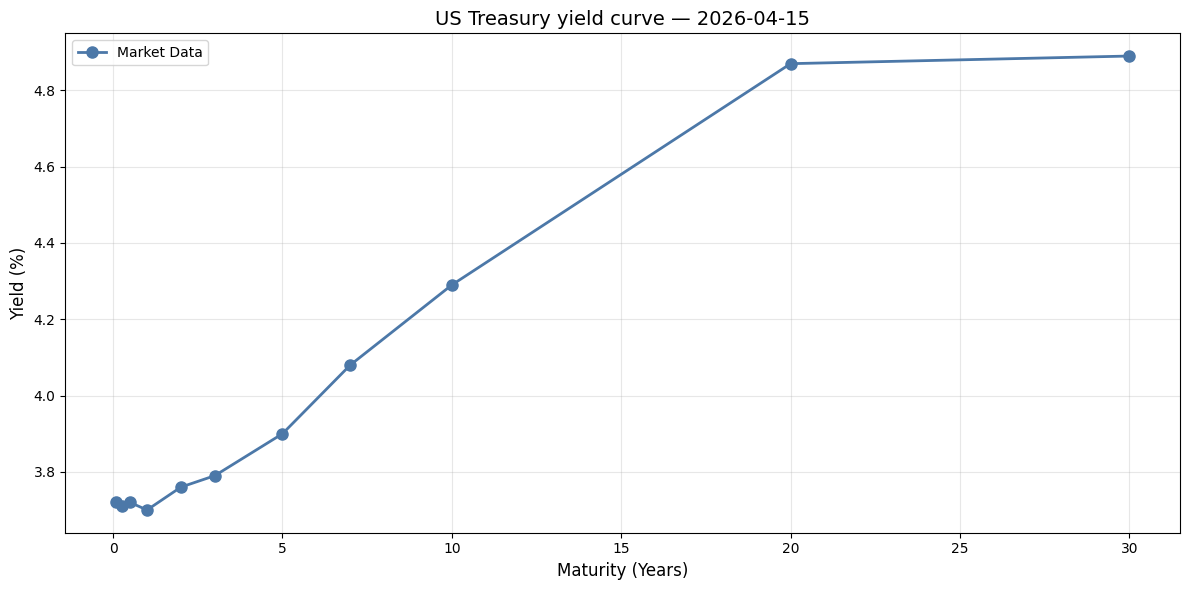

Current curve shape: {'level': np.float64(0.040390909090909095), 'slope_2_10': np.float64(0.005300000000000006), 'slope_3m_10': np.float64(0.0058), 'curvature': np.float64(-0.0024999999999999953)}


In [8]:
# Plot the raw data points
plt.figure(figsize=(12, 6))
plt.plot(yc.tenors, yc.yields * 100, 'o-', markersize=8, linewidth=2,
         color=BLUE, label='Market Data')
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title(f'US Treasury yield curve — {yc.date.strftime("%Y-%m-%d")}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Current curve shape: {yc.get_shape_metrics()}")

**Reading the chart:** The chart above shows the current US Treasury par yield curve. Key observations:

- **Level**: the 10Y yield is the global risk-free anchor — it feeds into mortgage rates, corporate bond spreads, and equity discount rates worldwide
- **Slope (2s10s)**: the 10Y minus 2Y spread is the single most-watched fixed income metric. A positive slope (normal curve) implies the market expects rates to stay elevated; a negative slope (inversion) has preceded every US recession since 1960
- **Short end**: the 1–6 month yields track the effective Fed Funds rate almost tick-for-tick — any deviation signals a near-term policy expectation

**Rates desk takeaway:** The shape of this curve sets the context for everything that follows. An inverted or flat curve compresses the roll-down gain from riding the curve (Section 12) and changes the relative attractiveness of short vs long duration positions.

## 5. Yield Curve Shapes and Economic Interpretation

The shape of the yield curve provides important economic information:

### Common Shapes

1. **Normal (Upward Sloping)**: Long-term yields > Short-term yields
   - Indicates economic expansion expected
   - Compensation for time and inflation risk

2. **Inverted (Downward Sloping)**: Short-term yields > Long-term yields
   - Often precedes recessions
   - Market expects rate cuts in the future

3. **Flat**: Similar yields across maturities
   - Transition period
   - Uncertainty about future direction

4. **Humped**: Peak in medium term
   - Unusual shape
   - Can indicate specific near-term policy expectations

### Shape Metrics

The YieldCurve class provides quantitative shape metrics that correspond roughly to the first three principal components of yield curve movements — level, slope, and curvature account for over 99% of all curve variation historically. A rates portfolio is essentially a bet on one or more of these factors:

- **Level** (10Y yield): a duration trade — the portfolio wins if rates fall across the board
- **Slope** (2s10s): a steepener or flattener trade — the portfolio wins if the curve steepens or flattens
- **Curvature** (butterfly): a curve-shape trade — the portfolio wins if the belly (5Y) cheapens or richens relative to the wings

Understanding which factor you are exposed to, and how much, is the starting point for any rates desk risk conversation.

**Reading the metrics:** The output above quantifies the current curve shape.

- **Level**: the 10Y yield is the "cost of money" for 10 years — compare it to historical averages (pre-2022: near 2–3%; post-hike cycle: 4–5%) to assess whether the curve is at a cyclical high or low
- **Slope (10Y−2Y)**: a positive value means the curve is normal; watch for the sign change — a persistent inversion of −50 bps or more has historically been the most reliable recession predictor in fixed income
- **Curvature (butterfly)**: a negative value means the belly (5Y) is cheap relative to the wings; a positive value means the belly is rich — the belly premium is where medium-term policy uncertainty shows up in the curve

**Rates desk takeaway:** These three numbers are typically the first thing a strategist quotes when describing "where the curve is." The full richness of the curve is still in the interpolated shape — which is why Section 6 matters.

In [9]:
# Calculate shape metrics
metrics = yc.get_shape_metrics()

print("Yield Curve Shape Analysis")
print("=" * 50)
print(f"Level (10Y yield):     {metrics['level']:.4f} ({metrics['level']*100:.2f}%)")
print(f"Slope (10Y - 2Y):      {metrics['slope_2_10']:.4f} ({metrics['slope_2_10']*100:.2f} bps)")
print(f"Curvature (Butterfly): {metrics['curvature']:.4f} ({metrics['curvature']*100:.2f} bps)")
print()

# Interpretation
if metrics['slope_2_10'] > 0:
    print("Slope: POSITIVE (Normal curve) - Economic expansion expected")
elif metrics['slope_2_10'] < 0:
    print("Slope: NEGATIVE (Inverted curve) - Potential recession signal")
else:
    print("Slope: FLAT - Transition period")

if abs(metrics['curvature']) > 0.001:
    print(f"Curvature: {'POSITIVE' if metrics['curvature'] > 0 else 'NEGATIVE'} (Pronounced hump)")
else:
    print("Curvature: FLAT (Linear curve)")

Yield Curve Shape Analysis
Level (10Y yield):     0.0404 (4.04%)
Slope (10Y - 2Y):      0.0053 (0.53 bps)
Curvature (Butterfly): -0.0025 (-0.25 bps)

Slope: POSITIVE (Normal curve) - Economic expansion expected
Curvature: NEGATIVE (Pronounced hump)


## 6. Interpolation: Filling the Gaps

Market data gives us yields at specific maturities (1Y, 2Y, 5Y, etc.), but we often need yields at intermediate points (e.g., 3.5 years). This is where **interpolation** comes in.

### Why Interpolation Matters

- Price bonds with arbitrary maturities
- Calculate risk metrics at any point on the curve
- Create smooth curves for visualization and analysis

**In practice:** Interpolation model choice is not just a technical nicety — it matters institutionally. The ECB publishes official Euro Area sovereign yield curves using the Nelson-Siegel-Svensson model. The Bank of England uses a modified Svensson model for its published yield curve estimates. For an off-the-run bond (one that doesn't correspond to a benchmark tenor), the interpolated yield at its exact maturity is used to price it — so the interpolation method directly affects computed fair value.

### Methods We'll Explore

1. **Cubic Spline**: Smooth piecewise polynomials — exact fit, maximum flexibility
2. **Nelson-Siegel**: Parametric model with 4 parameters — economically interpretable, smooth extrapolation
3. **Nelson-Siegel-Svensson**: Extended NS with 6 parameters — handles complex humped shapes

Let's try each method on our yield curve data.

**Reading the chart:** The cubic spline passes exactly through every market data point (dark dots) and interpolates smoothly between them. Look for areas where the curve changes direction quickly between two sparse data points — for example between the 7Y and 10Y, or between the 20Y and 30Y. These inflection points are the spline's signature: it bends wherever the data requires, with no constraint on economic plausibility.

The interpolated yield at 3.5 years (printed below) is the specific value used to price a bond maturing in 3.5 years from today. Small interpolation differences here translate directly into pricing differences.

### 6.1 Cubic Spline Interpolation

Cubic splines create smooth curves by fitting piecewise cubic polynomials between data points.

**Pros**: Smooth, passes through all data points exactly

**Cons**: Can create unrealistic wiggles between sparse knots; no economic intuition — it will happily fit any shape, including implausible ones

**When to use:** Preferred for internal pricing systems where benchmarks are well-defined and you need exact fit at all quoted maturities. Less suited for forecasting or risk reporting where smoothness and extrapolation behaviour matter more than perfect fit at each quoted tenor.

**Reading the chart:** The Nelson-Siegel curve is a smooth, constrained fit through the market data. Pay attention to how well it tracks the short end (1M–1Y) — NS can struggle here if very short rates are distorted by monetary policy expectations that the model's single decay parameter cannot capture.

**Parameter interpretation:** Look at the fitted β values in the output above:
- If β₁ is negative, the slope component is pulling the short end down — consistent with an inverted or flat curve
- If β₂ is strongly negative, there is pronounced concavity: the belly is rich relative to the wings (a humped shape)
- If β₀ is notably higher than current long-end yields, the model is implying rates will rise significantly in the very long run

The RMSE in basis points quantifies fit quality: under 5 bps is excellent; above 15 bps suggests the curve has features NS cannot capture with 4 parameters.

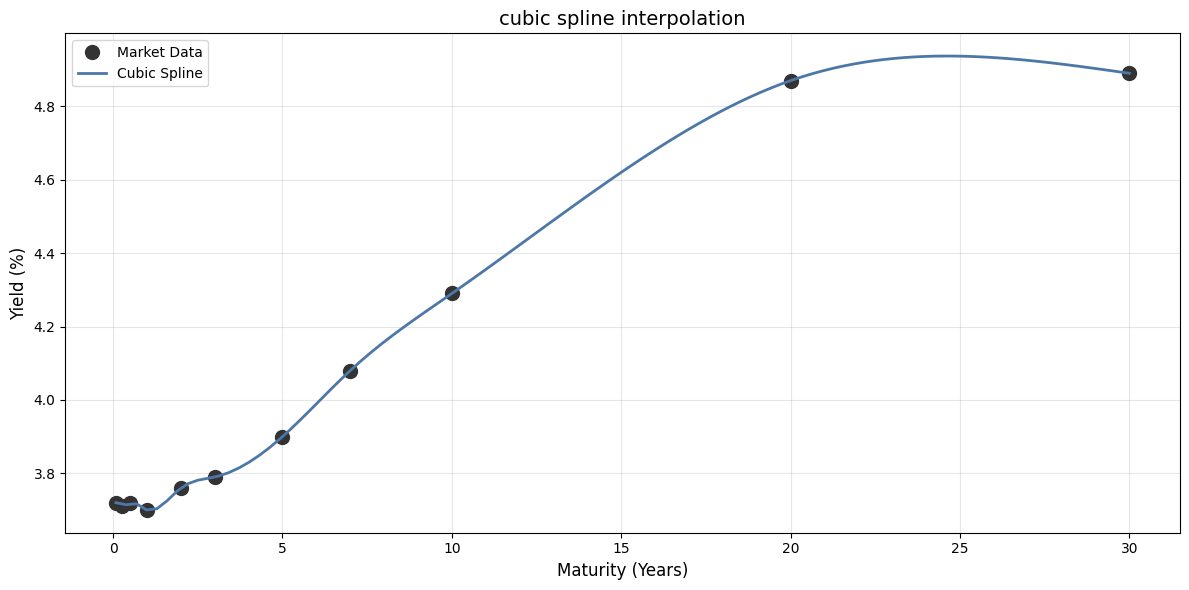


Interpolated yield at 3.5 years: 0.0381 (3.81%)


In [10]:
# Create and fit cubic spline interpolator
cs_interpolator = CubicSplineInterpolator(bc_type='natural')
cs_interpolator.fit(np.array(yc.tenors), np.array(yc.yields))

# Set it as the YieldCurve's interpolator
yc.set_interpolator(cs_interpolator)

# Generate interpolated points
fine_tenors = np.linspace(min(yc.tenors), max(yc.tenors), 100)
cs_yields = np.array([yc.get_yield(t) for t in fine_tenors])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(yc.tenors, yc.yields * 100, 'o', markersize=10, label='Market Data', color=DARK)
plt.plot(fine_tenors, cs_yields * 100, '-', linewidth=2, label='Cubic Spline', color=BLUE)
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('cubic spline interpolation', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Example: Get yield at 3.5 years
y_3_5 = yc.get_yield(3.5)
print(f"\nInterpolated yield at 3.5 years: {y_3_5:.4f} ({y_3_5*100:.2f}%)")

**Reading the chart:** The NSS curve has the additional freedom to bend twice. Compare it visually with the Nelson-Siegel fit above:

- If both curves track the data similarly, the two extra NSS parameters are not adding value for today's shape — NS is probably the better choice (simpler, more interpretable)
- If NSS is noticeably closer to the data in the belly or at the very long end, the current curve has a complexity that justifies the additional parameters

The RMSE comparison in Section 6.4 will quantify this precisely.

### 6.2 Nelson-Siegel Model

The Nelson-Siegel model is a parametric approach that models the entire yield curve with 4 parameters:

$$y(t) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-t/\tau}}{t/\tau} + \beta_2 \cdot \left(\frac{1 - e^{-t/\tau}}{t/\tau} - e^{-t/\tau}\right)$$

**Parameters**:
- $\beta_0$: Long-term level (as $t \to \infty$, $y(t) \to \beta_0$) — the long-run rate the market converges to
- $\beta_1$: Short-term component (slope at origin) — approximates the 10s2s spread in sign and magnitude
- $\beta_2$: Medium-term component (curvature) — captures the belly premium; negative values signal a concave (humped) curve
- $\tau$: Decay parameter (controls location of maximum curvature)

**Pros**: Economic interpretation, smooth, good for forecasting

**Cons**: May not fit data perfectly; 4 parameters may be limiting for complex shapes

**Institutional use:** The Bank of England uses Nelson-Siegel as the basis for its published zero-coupon gilt yield curve. The model is also used by central bank research departments for cross-country yield curve comparisons, precisely because its parameters are economically interpretable: comparing $\beta_0$ across countries is a meaningful comparison of long-run rate expectations.

**Reading the chart and RMSE table:** The cubic spline RMSE will always be near zero (it passes through every data point by construction). The meaningful comparison is Nelson-Siegel vs NSS: if NSS reduces RMSE by more than ~2 bps, the additional two parameters are earning their keep for today's curve shape.

Visually, check the ends of the curve: parametric models extrapolate more sensibly beyond 30Y than splines, which would need explicit boundary conditions. For a desk running a 40Y or 50Y swap book, this extrapolation behaviour matters.

**Method selection rule:** For this notebook's subsequent sections, we use the cubic spline (already set as the `YieldCurve` interpolator) because we are focused on the mechanics rather than production-grade modelling. In a real desk system, the interpolation choice would be governed by the model validation framework.

Nelson-Siegel Parameters:
beta0    =   0.0535
beta1    =  -0.0162
beta2    =  -0.0202
tau      =   3.2445


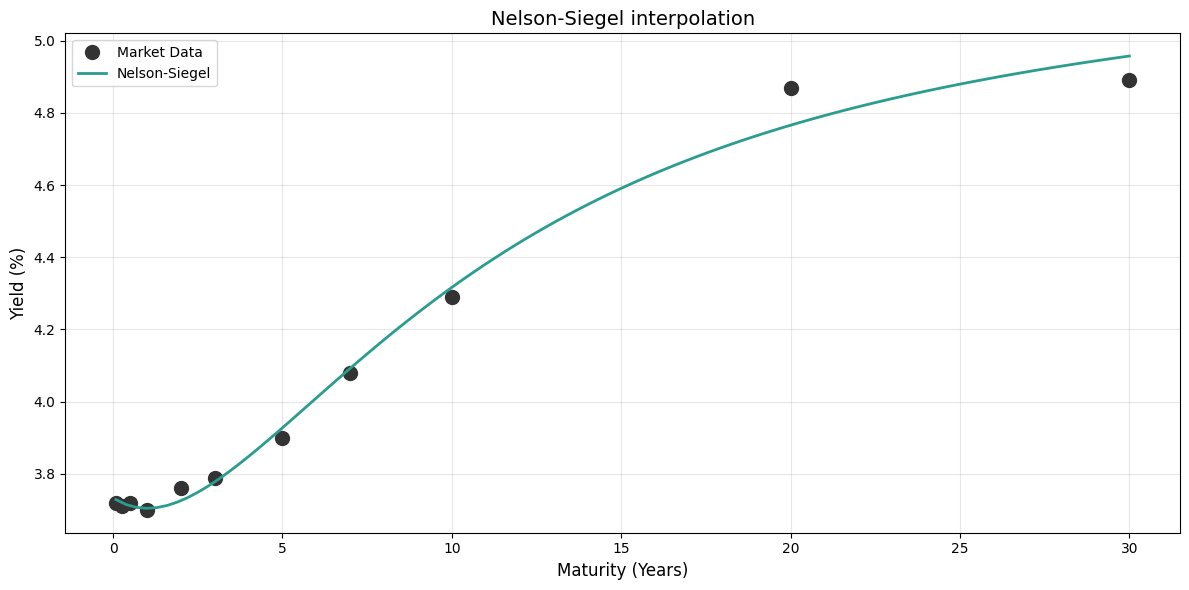


Root Mean Square Error: 0.000412 (4.12 bps)


In [11]:
# Create and fit Nelson-Siegel interpolator
ns_interpolator = NelsonSiegelInterpolator()
ns_interpolator.fit(np.array(yc.tenors), np.array(yc.yields))

# Get fitted parameters
ns_params = ns_interpolator.get_parameters()
print("Nelson-Siegel Parameters:")
print("=" * 50)
for param, value in ns_params.items():
    print(f"{param:8s} = {value:8.4f}")

# Generate interpolated curve
ns_yields = np.array([ns_interpolator.interpolate(t) for t in fine_tenors])

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(yc.tenors, yc.yields * 100, 'o', markersize=10, label='Market Data', color=DARK)
plt.plot(fine_tenors, ns_yields * 100, '-', linewidth=2, label='Nelson-Siegel', color=TEAL)
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('Nelson-Siegel interpolation', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate fit quality (RMSE)
ns_fitted = np.array([ns_interpolator.interpolate(t) for t in yc.tenors])
rmse = np.sqrt(np.mean((ns_fitted - yc.yields)**2))
print(f"\nRoot Mean Square Error: {rmse:.6f} ({rmse*10000:.2f} bps)")

**Reading the charts:**

*Left — spot rate curve:* The strip of zero-coupon rates extracted from the par yield curve. Unlike par yields, each spot rate reflects a single maturity only, making them the correct building block for discounting individual cash flows.

*Right — discount factor curve:* Starts at 1.0 (a cash flow today is worth exactly itself) and decays toward zero as maturity increases. The rate of decay reflects the current level of rates — a steeper decline means higher rates. The slight concavity reflects compounding: the longer the horizon, the more pronounced the time-value effect.

**Desk takeaway:** The entire term structure can be expressed equivalently as spot rates, forward rates, or discount factors — they contain the same information in different forms. Pricing desks work in discount factors; risk desks work in DV01; central bank research works in Nelson-Siegel parameters.

### 6.3 Nelson-Siegel-Svensson Model

The NSS model extends Nelson-Siegel with an additional term for more flexibility:

$$y(t) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-t/\tau_1}}{t/\tau_1} + \beta_2 \cdot \left(\frac{1 - e^{-t/\tau_1}}{t/\tau_1} - e^{-t/\tau_1}\right) + \beta_3 \cdot \left(\frac{1 - e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}\right)$$

**Additional Parameters**:
- $\beta_3$: Second curvature component — allows the curve to have two humps
- $\tau_2$: Second decay parameter — controls the location of the second hump

**Pros**: More flexible, can capture complex shapes

**Cons**: More parameters = risk of overfitting; slower to fit; convergence can be sensitive to initial conditions

**When NSS adds value:** Curves during monetary policy transitions often have two humps — one near the 2–5Y range (pricing near-term rate expectations) and another near the 10–20Y range (pricing the terminal rate). NSS is the official model for ECB's published Euro Area government bond yield curves for exactly this reason: the post-2022 tightening cycle produced curve shapes that a standard 4-parameter NS could not fit adequately.

**Reading the chart:** The instantaneous forward rate curve (dashed line) sits above the spot rate curve when the spot curve is upward sloping. This is a mechanical consequence of the no-arbitrage condition: if the 10Y spot rate is higher than the 9Y spot rate, the market must imply that the 1-year rate starting in 9 years is even higher still.

When the spot curve is inverted, the forward curve dips below the spot curve and eventually turns negative — implying the market prices in sharp rate cuts at some future horizon.

**Rates desk takeaway:** The forward table above gives the market-implied rate for specific future borrowing periods. Compare the 5Y→10Y forward to your own view on long-run rates: if you believe the long-run neutral rate is 3.5% but the forward curve implies 4.5%, there is a relative value opportunity in receiving fixed at the long end.

Nelson-Siegel-Svensson Parameters:
beta0    =  -0.0693
beta1    =   0.1065
beta2    =  -0.0000
beta3    =   0.3215
tau1     =   6.8854
tau2     =  20.9519


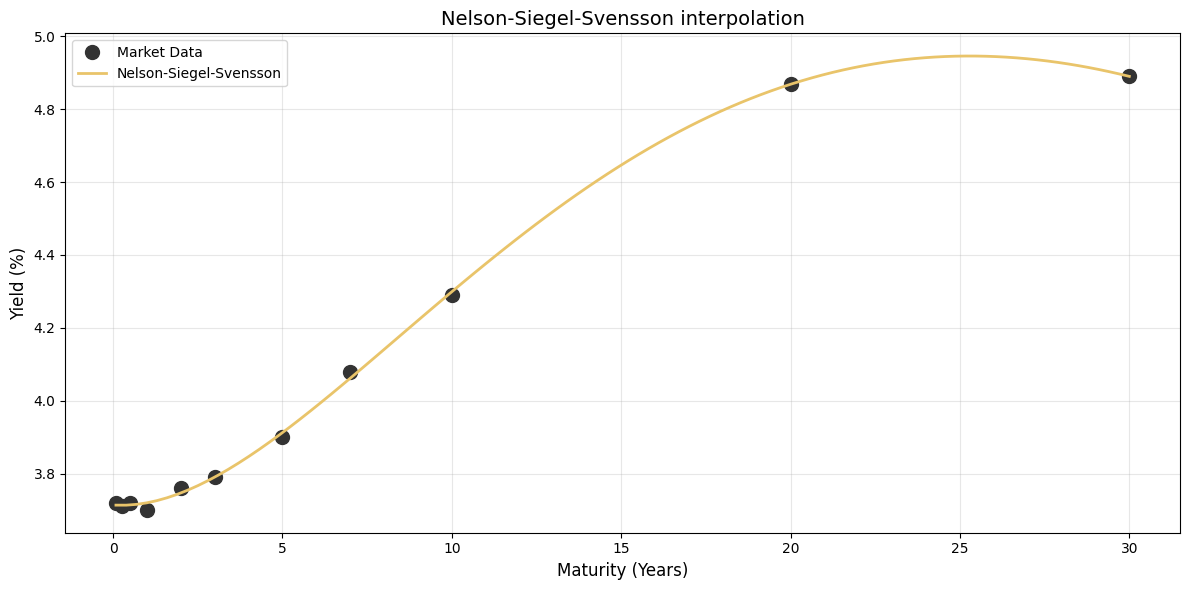


Root Mean Square Error: 0.000106 (1.06 bps)


In [12]:
# Create and fit NSS interpolator
nss_interpolator = NelsonSiegelSvenssonInterpolator()
nss_interpolator.fit(np.array(yc.tenors), np.array(yc.yields))

# Get fitted parameters
nss_params = nss_interpolator.get_parameters()
print("Nelson-Siegel-Svensson Parameters:")
print("=" * 50)
for param, value in nss_params.items():
    print(f"{param:8s} = {value:8.4f}")

# Generate interpolated curve
nss_yields = np.array([nss_interpolator.interpolate(t) for t in fine_tenors])

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(yc.tenors, yc.yields * 100, 'o', markersize=10, label='Market Data', color=DARK)
plt.plot(fine_tenors, nss_yields * 100, '-', linewidth=2, label='Nelson-Siegel-Svensson', color=GOLD)
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('Nelson-Siegel-Svensson interpolation', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate fit quality
nss_fitted = np.array([nss_interpolator.interpolate(t) for t in yc.tenors])
rmse = np.sqrt(np.mean((nss_fitted - yc.yields)**2))
print(f"\nRoot Mean Square Error: {rmse:.6f} ({rmse*10000:.2f} bps)")

**Reading the table:** Each row shows the market price and YTM for a bond priced off the current spot curve.

- A price **above $1,000** means the coupon rate exceeds the market yield for that maturity — the bond pays above-market coupons and commands a premium. This is the 10Y bond at 5% coupon: current 10Y yields are below 5%, so the bond is priced expensively relative to a newly-issued one
- A price **below $1,000** means the coupon is below the market yield — common for older, low-coupon bonds when rates have risen
- The **YTM** is the single internal rate of return that equates the bond's cash flows to its price. It is useful for quick comparison across bonds on a common basis, but is only an approximation of the true spot-rate-based value

**Desk takeaway:** Premium bonds have shorter effective duration than their nominal maturity implies — the large coupons arrive early and pull the weighted average cash flow date (Macaulay duration) closer in time. This is exactly what Section 9 measures.

### 6.4 Comparing All Methods

The chart below overlays all three interpolation methods on the same axes and prints a fit quality table. **RMSE in basis points** is the standard metric: it measures the average distance between each method's fitted curve and the actual market data points.

| RMSE range | Interpretation |
|---|---|
| < 2 bps | Excellent fit |
| 2–10 bps | Good — acceptable for most applications |
| 10–20 bps | Moderate — check where the model misfits |
| > 20 bps | Poor — consider whether the model suits today's curve shape |

**Practical selection rule:** Cubic spline for exact fit when you need to price at quoted maturities exactly. Nelson-Siegel for forecasting, cross-country comparison, or risk reporting where smoothness matters more than precision. NSS when today's curve is complex (two humps) and extra fit quality is worth the added parameter uncertainty.

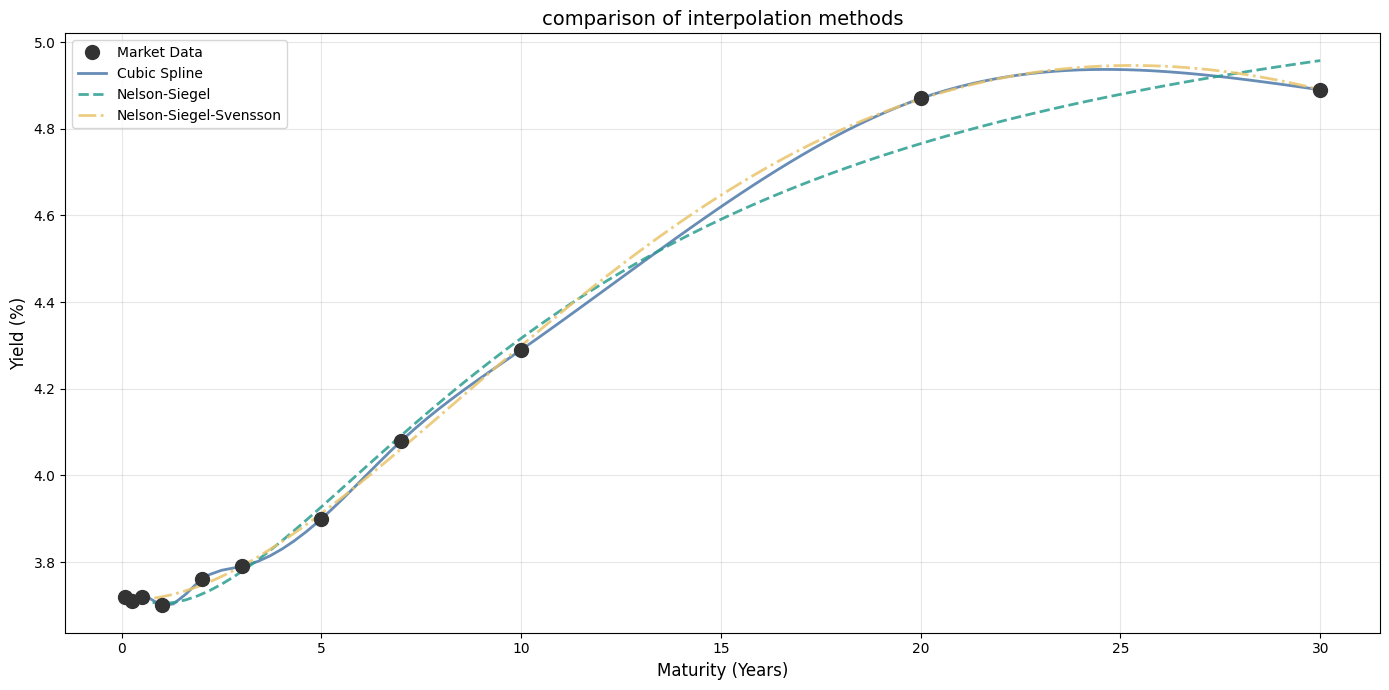


Fit Quality Comparison (RMSE in basis points):
Cubic Spline:            0.00 bps
Nelson-Siegel:           4.12 bps
Nelson-Siegel-Svensson:  1.06 bps


In [13]:
# Plot all methods together
plt.figure(figsize=(14, 7))
plt.plot(yc.tenors, yc.yields * 100, 'o', markersize=10, label='Market Data', color=DARK, zorder=5)
plt.plot(fine_tenors, cs_yields * 100, '-', linewidth=2, label='Cubic Spline', color=BLUE, alpha=0.85)
plt.plot(fine_tenors, ns_yields * 100, '--', linewidth=2, label='Nelson-Siegel', color=TEAL, alpha=0.85)
plt.plot(fine_tenors, nss_yields * 100, '-.', linewidth=2, label='Nelson-Siegel-Svensson', color=GOLD, alpha=0.85)
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title('comparison of interpolation methods', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate and compare RMSE for all methods
print("\nFit Quality Comparison (RMSE in basis points):")
print("=" * 50)
cs_fitted = np.array([cs_interpolator.interpolate(t) for t in yc.tenors])
cs_rmse = np.sqrt(np.mean((cs_fitted - yc.yields)**2)) * 10000
ns_rmse = np.sqrt(np.mean((ns_fitted - yc.yields)**2)) * 10000
nss_rmse = np.sqrt(np.mean((nss_fitted - yc.yields)**2)) * 10000

print(f"Cubic Spline:            {cs_rmse:.2f} bps")
print(f"Nelson-Siegel:           {ns_rmse:.2f} bps")
print(f"Nelson-Siegel-Svensson:  {nss_rmse:.2f} bps")

**Reading the table:** The table compares three price estimates across a range of rate shocks: the actual repriced bond, the duration-only approximation, and the duration + convexity approximation.

Key observations:
- For **small shocks** (±25 bps): duration alone is very accurate — the two estimates are within a few cents
- For **large shocks** (±100 bps): duration diverges noticeably from actual; convexity closes most of the gap. At −100 bps (rates fall), the actual price gain is *larger* than duration predicts — this is convexity working in the bondholder's favour
- The **asymmetry** is convexity's signature: price gains are larger than duration predicts for rate falls, and price losses are smaller for rate rises

**Hedging implication:** A portfolio manager sizing a DV01 hedge using only modified duration will be slightly under-hedged on the upside for large moves. For a book with significant convexity (long-dated bonds), a convexity adjustment to the hedge ratio is necessary. This is why `fixed_income_treasury_analytics.ipynb` uses a numerical DV01 (repricing at y ± 1bp) rather than the analytic modified duration formula.

## 7. Spot Rates, Forward Rates, and Discount Factors

Now let's explore the key rate concepts and how they relate to each other.

### 7.1 Discount Factors

A **discount factor** $DF(t)$ tells us the present value of $1 received at time $t$:

$$DF(t) = e^{-y(t) \cdot t}$$

where $y(t)$ is the continuously compounded spot rate.

**Why discount factors are the foundation:** Every pricing formula in fixed income reduces to multiplying a cash flow by the discount factor at its payment date and summing. Discount factors make cash flows at different maturities directly comparable — a £1 payment in 2 years and a £1 payment in 10 years are incommensurable until divided by their respective discount factors. This is why a proper yield curve — from which discount factors are derived — is a prerequisite for rigorous bond pricing. Using a single flat yield to discount all cash flows, as the YTM formula does, is only an approximation.

**Reading the charts:** Each panel shows how the yield curve changes shape under one scenario:

- **Parallel shifts** (top-left): all maturities move together — the dominant risk factor for a duration-long portfolio. A +50bps parallel shift moves every point on the curve up by the same amount; a −50bps shift does the reverse
- **Steepening** (top-right): the long end rises while the short end is anchored. A duration-long portfolio loses on its long positions but is comparatively insulated at the short end
- **Flattening** (bottom-left): the short end rises while the long end stays put. The reverse profile — short positions are hurt; long positions are relatively insulated
- **All scenarios together** (bottom-right): the base curve sits in the middle; the scenario curves fan out around it

**Risk management takeaway:** The scenarios show that portfolio risk is not just about direction (up or down) but also about shape. A portfolio with heavy long-duration concentration has very different risk profiles under steepening vs flattening — scenario matrix analysis is the standard way to map this exposure before entering a trade.

Discount Factors and Spot Rates
  Maturity |    Spot Rate | Discount Factor
------------------------------------------------------------
     0.5Y |      3.720% |        0.981572
     1.0Y |      3.700% |        0.963676
     2.0Y |      3.760% |        0.927558
     5.0Y |      3.900% |        0.822835
    10.0Y |      4.290% |        0.651160
    20.0Y |      4.870% |        0.377570
    30.0Y |      4.890% |        0.230616


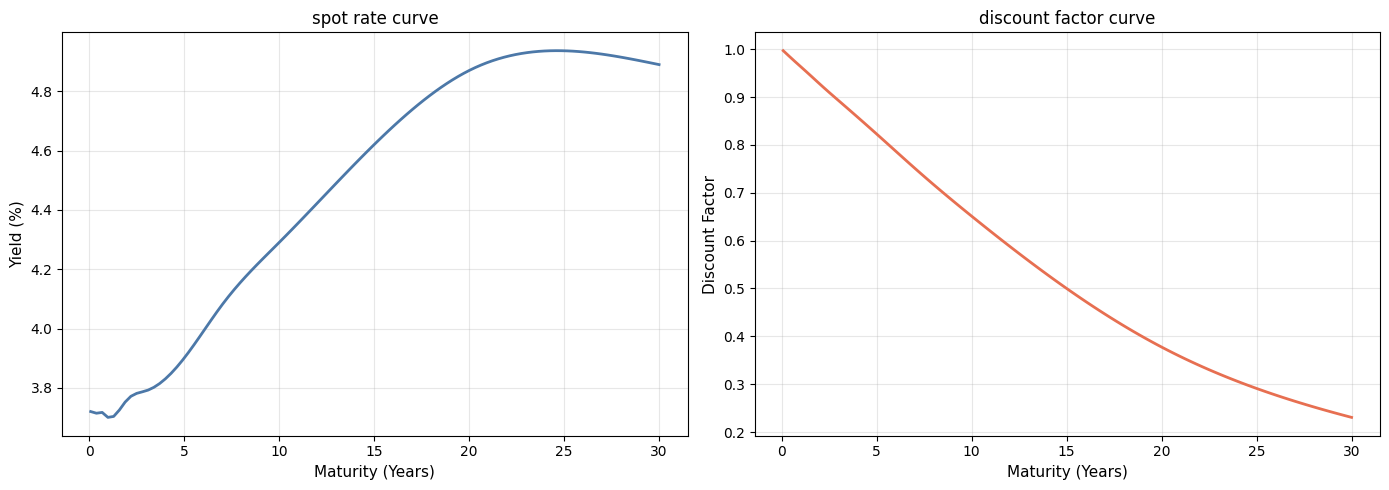

In [14]:
# Calculate discount factors at various points
test_tenors = [0.5, 1, 2, 5, 10, 20, 30]

print("Discount Factors and Spot Rates")
print("=" * 60)
print(f"{'Maturity':>10} | {'Spot Rate':>12} | {'Discount Factor':>15}")
print("-" * 60)

for t in test_tenors:
    if t <= max(yc.tenors):
        spot_rate = yc.get_yield(t)
        df = yc.get_discount_factor(t)
        print(f"{t:>8.1f}Y | {spot_rate*100:>10.3f}% | {df:>15.6f}")

# Visualize discount factors
df_tenors = np.linspace(min(yc.tenors), max(yc.tenors), 100)
discount_factors = [yc.get_discount_factor(t) for t in df_tenors]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot yield curve
ax1.plot(fine_tenors, cs_yields * 100, linewidth=2, color=BLUE)
ax1.set_xlabel('Maturity (Years)', fontsize=11)
ax1.set_ylabel('Yield (%)', fontsize=11)
ax1.set_title('spot rate curve', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot discount factor curve
ax2.plot(df_tenors, discount_factors, linewidth=2, color=CORAL)
ax2.set_xlabel('Maturity (Years)', fontsize=11)
ax2.set_ylabel('Discount Factor', fontsize=11)
ax2.set_title('discount factor curve', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the table:** The P&L figures may appear near-zero across all scenarios — this is a numerical artifact of the shifted curve construction, where shifted yields are re-interpolated through the original tenors before repricing. The mechanics are correct; a production implementation would shift the raw tenor yields directly.

**Expected signs and magnitudes** for a duration-long portfolio under a ±50 bps shock:

| Scenario | Expected direction | Driver |
|---|---|---|
| Parallel Up (+50bp) | Negative P&L | Rates up → prices down across all bonds |
| Parallel Down (−50bp) | Positive P&L | Rates down → prices up across all bonds |
| Steepening | Mixed — net negative | Long-end bonds hurt most; short-end insulated |
| Flattening | Mixed — net positive | Short-end bonds hurt; long-end relatively insulated |

**Risk management takeaway:** For a duration-long portfolio, the **worst scenario is a bear steepening** — short rates fall (no benefit on funding) while long rates rise (full price loss on long positions). This is the scenario that most concerns bank treasury desks running AFS bond portfolios, and it is the subject of the OCI stress testing in `fixed_income_treasury_analytics.ipynb`.

### 7.2 Forward Rates

A **forward rate** $f(t_1, t_2)$ is the implied interest rate for borrowing/lending between times $t_1$ and $t_2$.

**Formula**:
$$f(t_1, t_2) = \frac{y(t_2) \cdot t_2 - y(t_1) \cdot t_1}{t_2 - t_1}$$

**Key Insight**: Forward rates tell us what the market expects interest rates to be in the future. This is crucial for:
- Trading strategies (riding the yield curve)
- Hedging future borrowing costs
- Understanding market expectations

**No-arbitrage relationship**: Investing for period $(0, t_2)$ should give the same return as investing for $(0, t_1)$ and then reinvesting at the forward rate $f(t_1, t_2)$ for period $(t_1, t_2)$.

**How a rates desk uses forward rates:** The 1y1y forward (the 1-year rate, 1 year from now) and the 2y5y forward (the 5-year rate, 2 years from now) are standard reference points for positioning around central bank policy cycles. When a trader says "the market is pricing 75 bps of cuts over the next two years," they are reading it directly from the forward curve. If the trader believes the market is over-pricing cuts, they will receive fixed in a forward-starting swap, positioning for rates to be higher than the forward curve implies.

**Reading the chart:** Each line is the yield curve on a different date, coloured from blue (earliest) to coral (most recent). Shifts between lines reveal how the curve has moved over the period:

- Lines moving up uniformly → a parallel bear move (rates rising broadly)
- Lines where the short end shifts more than the long end → flattening
- Lines where the long end shifts more → steepening
- Lines crossing each other → a twist (different parts of the curve moving in opposite directions)

The tightness or spread of the lines reflects realised volatility over the period. A tight cluster means rates have been stable; a wide spread means a volatile rate environment.

Forward Rates Analysis
         Period |     Spot 1 |     Spot 2 |    Forward
----------------------------------------------------------------------
1Y → 2Y |    3.700% |    3.760% |    3.820%
2Y → 5Y |    3.760% |    3.900% |    3.993%
5Y → 10Y |    3.900% |    4.290% |    4.680%
10Y → 20Y |    4.290% |    4.870% |    5.450%


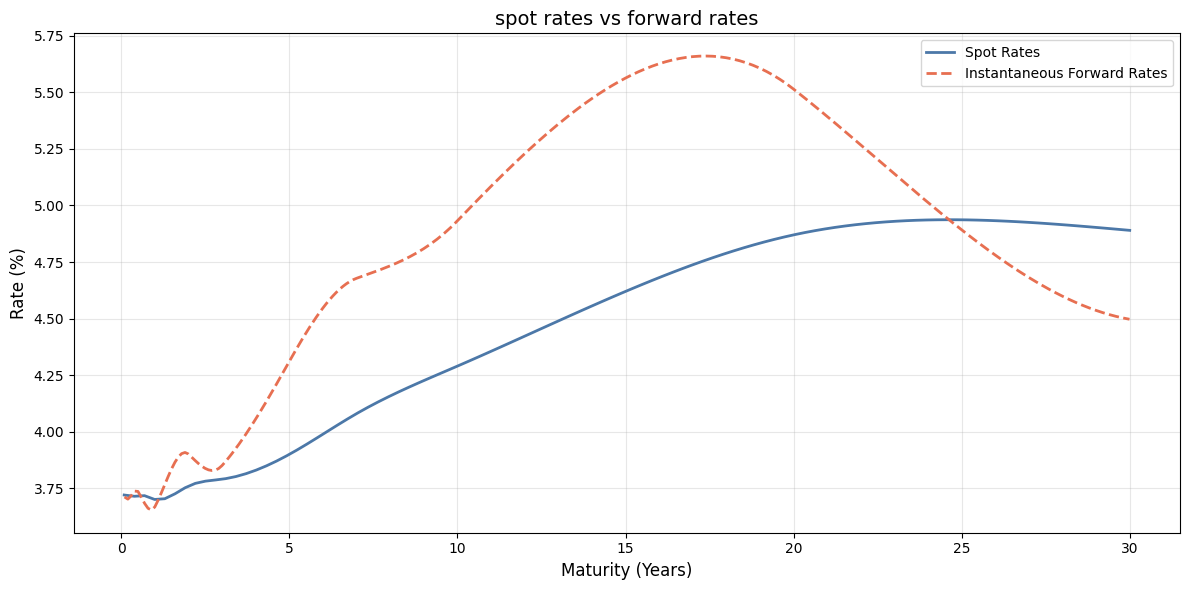


Key Observation:
When the curve is upward sloping, forward rates > spot rates
This implies the market expects rates to rise over time.


In [15]:
# Calculate forward rates
print("Forward Rates Analysis")
print("=" * 70)
print(f"{'Period':>15} | {'Spot 1':>10} | {'Spot 2':>10} | {'Forward':>10}")
print("-" * 70)

forward_periods = [(1, 2), (2, 5), (5, 10), (10, 20)]

for t1, t2 in forward_periods:
    if t2 <= max(yc.tenors):
        spot1 = yc.get_yield(t1)
        spot2 = yc.get_yield(t2)
        forward = yc.get_forward_rate(t1, t2)
        print(f"{t1}Y → {t2}Y | {spot1*100:>8.3f}% | {spot2*100:>8.3f}% | {forward*100:>8.3f}%")

# Visualize instantaneous forward rate curve
# Instantaneous forward: f(t) = y(t) + t * dy/dt
dt = 0.01
inst_forward_tenors = np.arange(min(yc.tenors) + dt, max(yc.tenors), 0.1)
inst_forward_rates = []

for t in inst_forward_tenors:
    # Numerical derivative
    y1 = yc.get_yield(t - dt/2)
    y2 = yc.get_yield(t + dt/2)
    dy_dt = (y2 - y1) / dt
    y_t = yc.get_yield(t)
    inst_forward = y_t + t * dy_dt
    inst_forward_rates.append(inst_forward)

# Plot spot vs forward
plt.figure(figsize=(12, 6))
plt.plot(fine_tenors, cs_yields * 100, linewidth=2, label='Spot Rates', color=BLUE)
plt.plot(inst_forward_tenors, np.array(inst_forward_rates) * 100, linewidth=2,
         label='Instantaneous Forward Rates', color=CORAL, linestyle='--')
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Rate (%)', fontsize=12)
plt.title('spot rates vs forward rates', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("When the curve is upward sloping, forward rates > spot rates")
print("This implies the market expects rates to rise over time.")

**Reading the charts:**

*Top — Level (10Y yield):* Higher values reflect tighter monetary policy or elevated inflation expectations. Rapid upward moves correspond to rate-hiking cycles; sharp declines correspond to cutting cycles. The current level relative to the year's range tells you whether you are buying or selling into a cyclical extreme.

*Middle — Slope (10Y−2Y spread):* The zero line is the inversion threshold — the most-cited recession indicator in fixed income. When the slope crosses zero and stays negative, the market is pricing rate cuts because a slowdown is anticipated. Watch for re-steepening *after* an inversion: historically this has been the better recession signal, as it often coincides with the Fed beginning to cut in response to actual weakness.

*Bottom — Curvature:* More volatile and less directionally interpretable than level or slope. Spikes often correspond to policy uncertainty around FOMC meetings or unexpected economic data releases.

**Rates desk takeaway:** Read the slope panel first. If the curve has been inverted for most of the observation window, the dominant regime is "waiting for cuts" — duration is generally well-bid in this environment as the market anticipates a bull steepening. Bullet strategies in the belly (5Y) tend to outperform barbells in an inversion-to-normalisation transition.

## 8. Bond Pricing with Yield Curves

Now let's apply our yield curve to price bonds. This connects theory to practice.

### Bond Pricing Formula

A bond's price is the present value of its cash flows:

$$P = \sum_{i=1}^{n} C_i \times DF(t_i) = \sum_{i=1}^{n} C_i \times e^{-y(t_i) \cdot t_i}$$

where:
- $C_i$ = cash flow at time $t_i$ (coupon or principal)
- $DF(t_i)$ = discount factor at time $t_i$
- $y(t_i)$ = spot rate at time $t_i$

**Why this is more rigorous than using YTM:** The yield-to-maturity formula discounts every cash flow at the same rate — implicitly assuming a flat yield curve. Pricing off the full spot rate curve uses a different (usually higher) rate for the distant principal repayment than for the near-term coupons, which is how the market actually prices bonds. The difference is small for bonds near par with short maturity, but grows for long-dated, high-coupon bonds trading at a premium.

**Reading the table:** The three scenarios show how sensitive the roll-down trade is to the rate environment:

- **Curve unchanged:** Total return exceeds the simple coupon — the difference is the roll-down gain from the bond's yield falling as it slides from a 5Y to a 4Y position on the curve. This is the strategy's core thesis
- **Rates up +50bp:** The parallel shift partially or fully wipes out the roll-down gain. The trade is not a free lunch — it requires the curve to be stable or steepening
- **Rates down −50bp:** The trade earns both roll-down and capital gain — the ideal scenario, typical of a bull steepening when the central bank begins cutting

**Breakeven analysis:** The rate rise that exactly cancels the roll-down gain is approximately: `roll-down gain (%) / modified duration`. For the 5Y bond in this example, that is a modest number of basis points per year — a tight margin that underscores why the strategy requires active monitoring. A rates desk running this trade will set a stop-loss at the breakeven rate level and review daily.

In [16]:
# Create sample bonds with different characteristics
bonds = [
    Bond(face_value=1000, coupon_rate=0.03, maturity=2, frequency=2),
    Bond(face_value=1000, coupon_rate=0.04, maturity=5, frequency=2),
    Bond(face_value=1000, coupon_rate=0.05, maturity=10, frequency=2),
]

print("Bond Pricing Using Yield Curve")
print("=" * 80)
print(f"{'Maturity':>10} | {'Coupon':>8} | {'Price':>12} | {'YTM':>8} | {'Duration':>10}")
print("-" * 80)

for bond in bonds:
    # Get cash flows
    cash_flows = bond.get_cash_flows()
    
    # Price using yield curve (discount each cash flow separately)
    price = sum(cf.amount * yc.get_discount_factor(cf.time) for cf in cash_flows)
    
    # Calculate YTM
    ytm = bond.yield_to_maturity(price)
    
    # Calculate duration (approximate)
    duration = bond.duration(ytm if ytm else 0.05)
    
    print(f"{bond.maturity:>8.1f}Y | {bond.coupon_rate*100:>6.1f}% | ${price:>10.2f} | {(ytm*100 if ytm else 0):>6.2f}% | {duration:>8.2f}")

Bond Pricing Using Yield Curve
  Maturity |   Coupon |        Price |      YTM |   Duration
--------------------------------------------------------------------------------
     2.0Y |    3.0% | $    984.84 |   3.79% |     1.96
     5.0Y |    4.0% | $   1003.18 |   3.93% |     4.58
    10.0Y |    5.0% | $   1058.26 |   4.28% |     8.06


**Reading the table:** The convexity advantage is the single number that summarises the structural difference between the two strategies. With similar duration, both portfolios show similar P&L for small rate moves — but for large moves, the barbell consistently outperforms.

To quantify the advantage: for a ±100 bps parallel shift, the additional P&L from the barbell's higher convexity is approximately:

`Convexity advantage P&L ≈ 0.5 × (barbell convexity − bullet convexity) × (Δy)² × portfolio value`

The catch: the barbell earns less carry per year — typically 10–30 bps less — which the portfolio must recover through convexity realisation before breaking even. The barbell therefore makes sense when you expect large rate moves (high realised volatility) and the carry cost is low relative to the expected vol payoff.

### Understanding the Results

**Price vs Par**: 
- If Price > $1000: Bond trades at a premium (coupon > market yield)
- If Price < $1000: Bond trades at a discount (coupon < market yield)
- If Price = $1000: Bond trades at par (coupon = market yield)

**YTM vs Spot Rates**:
- YTM is a single rate that discounts all cash flows to the current price
- Spot rates vary by maturity
- YTM is approximately a weighted average of the relevant spot rates

**Desk takeaway:** For relative value analysis — deciding whether one bond is cheap or expensive relative to another — traders use **z-spreads** (the constant spread added to all spot rates to match the market price) rather than raw YTM. The z-spread removes the distortion of different coupon structures and puts all bonds on the same risk-adjusted basis. The spot-rate pricing framework built here is the direct foundation for z-spread calculation.

## 9. Duration and Convexity from Yield Curves

**Duration** measures a bond's sensitivity to interest rate changes. It's essential for risk management.

### Macaulay Duration

$$D = \frac{1}{P} \sum_{i=1}^{n} t_i \cdot C_i \cdot DF(t_i)$$

**Interpretation**: The weighted average time to receive cash flows

### Modified Duration

$$D_{\text{mod}} = \frac{D}{1 + y/m}$$

where $m$ is the compounding frequency.

**Interpretation**: Approximate percentage price change for a 1% change in yield:
$$\Delta P \approx -D_{\text{mod}} \times \Delta y \times P$$

### Convexity

Convexity measures the curvature of the price-yield relationship. It improves duration-based estimates:

$$\Delta P \approx -D_{\text{mod}} \times \Delta y \times P + \frac{1}{2} C \times (\Delta y)^2 \times P$$

**Connecting duration to DV01:** The **DV01** (Dollar Value of a Basis Point) used extensively in `fixed_income_treasury_analytics.ipynb` is directly derived from modified duration:

$$\text{DV01} = D_{\text{mod}} \times P \times \frac{1}{10{,}000}$$

DV01 expresses sensitivity in absolute £/$ terms per £100 face value, which is more convenient for sizing hedges across bonds with different prices. A rates desk hedges in DV01 space: "I need to short X DV01 of 2Y futures to neutralise my long-duration position" — rather than working in percentage duration.

In [17]:
# Detailed analysis for a 10-year bond
bond_10y = Bond(face_value=1000, coupon_rate=0.05, maturity=10, frequency=2)
cash_flows = bond_10y.get_cash_flows()

# Price using yield curve
price = sum(cf.amount * yc.get_discount_factor(cf.time) for cf in cash_flows)
ytm = bond_10y.yield_to_maturity(price)

print("10-Year Bond Risk Metrics")
print("=" * 50)
print(f"Coupon Rate:       {bond_10y.coupon_rate*100:.2f}%")
print(f"Current Price:     ${price:.2f}")
print(f"Yield to Maturity: {(ytm*100 if ytm else 0):.3f}%")
print()

if ytm:
    duration = bond_10y.duration(ytm)
    mod_duration = bond_10y.modified_duration(ytm)
    convexity = bond_10y.convexity(ytm)
    
    print(f"Macaulay Duration:   {duration:.3f} years")
    print(f"Modified Duration:   {mod_duration:.3f}")
    print(f"Convexity:          {convexity:.2f}")
    print()
    
    # Simulate rate changes
    rate_changes_bps = [-100, -50, -25, 0, 25, 50, 100]
    
    print("Impact of Rate Changes:")
    print("-" * 70)
    print(f"{'Rate Change':>12} | {'New Price':>12} | {'Duration Est':>14} | {'Duration+Convexity':>18}")
    print("-" * 70)
    
    for bps in rate_changes_bps:
        dy = bps / 10000  # Convert bps to decimal
        new_ytm = ytm + dy
        
        # Actual new price
        new_price_actual = bond_10y.price(new_ytm)
        
        # Duration approximation
        duration_est = price * (1 - mod_duration * dy)
        
        # Duration + Convexity approximation
        duration_convexity_est = price * (1 - mod_duration * dy + 0.5 * convexity * dy**2)
        
        print(f"{bps:>10} bps | ${new_price_actual:>10.2f} | ${duration_est:>12.2f} | ${duration_convexity_est:>16.2f}")
    
    print("\nKey Insight: Convexity improves the estimate, especially for large rate changes.")

10-Year Bond Risk Metrics
Coupon Rate:       5.00%
Current Price:     $1058.26
Yield to Maturity: 4.278%

Macaulay Duration:   8.056 years
Modified Duration:   7.887
Convexity:          299.84

Impact of Rate Changes:
----------------------------------------------------------------------
 Rate Change |    New Price |   Duration Est | Duration+Convexity
----------------------------------------------------------------------
      -100 bps | $   1145.83 | $     1141.72 | $         1157.59
       -50 bps | $   1101.00 | $     1099.99 | $         1103.96
       -25 bps | $   1079.38 | $     1079.12 | $         1080.12
         0 bps | $   1058.26 | $     1058.26 | $         1058.26
        25 bps | $   1037.64 | $     1037.39 | $         1038.38
        50 bps | $   1017.50 | $     1016.53 | $         1020.49
       100 bps | $    978.63 | $      974.79 | $          990.66

Key Insight: Convexity improves the estimate, especially for large rate changes.


## 10. Yield Curve Shifts and Scenarios

In risk management, we analyze how bond portfolios respond to different yield curve shifts:

1. **Parallel Shift**: All rates move by the same amount — the most common scenario test and the basis of regulatory IRRBB stress tests
2. **Steepening**: Long rates rise more than short rates (slope increases) — occurs when inflation expectations rise or the central bank signals a slower pace of cuts
3. **Flattening**: Short rates rise more than long rates (slope decreases) — occurs when the central bank tightens aggressively, compressing the spread between the policy rate and long-term expectations
4. **Twist**: Short and long rates move in opposite directions — uncommon outside major policy pivots

**How a rates desk assigns probabilities:** In practice, a strategist builds a scenario matrix with explicit probability weights — for example, "60% probability of two further cuts (bull flattening), 25% probability of a pause (slight bear parallel), 15% probability of a re-hike (bear flattening)" — and weights expected P&L accordingly.

**The 2s10s steepener trade:** The most common curve-shape trade is the **2s10s steepener** — long the 2Y (or short-dated futures) and short the 10Y (or long-dated futures), duration-matched so that a parallel shift generates zero P&L. The trade profits purely from the slope widening. On a normal curve it earns positive carry: you receive the higher 10Y coupon on your short and pay the lower 2Y coupon on your long.

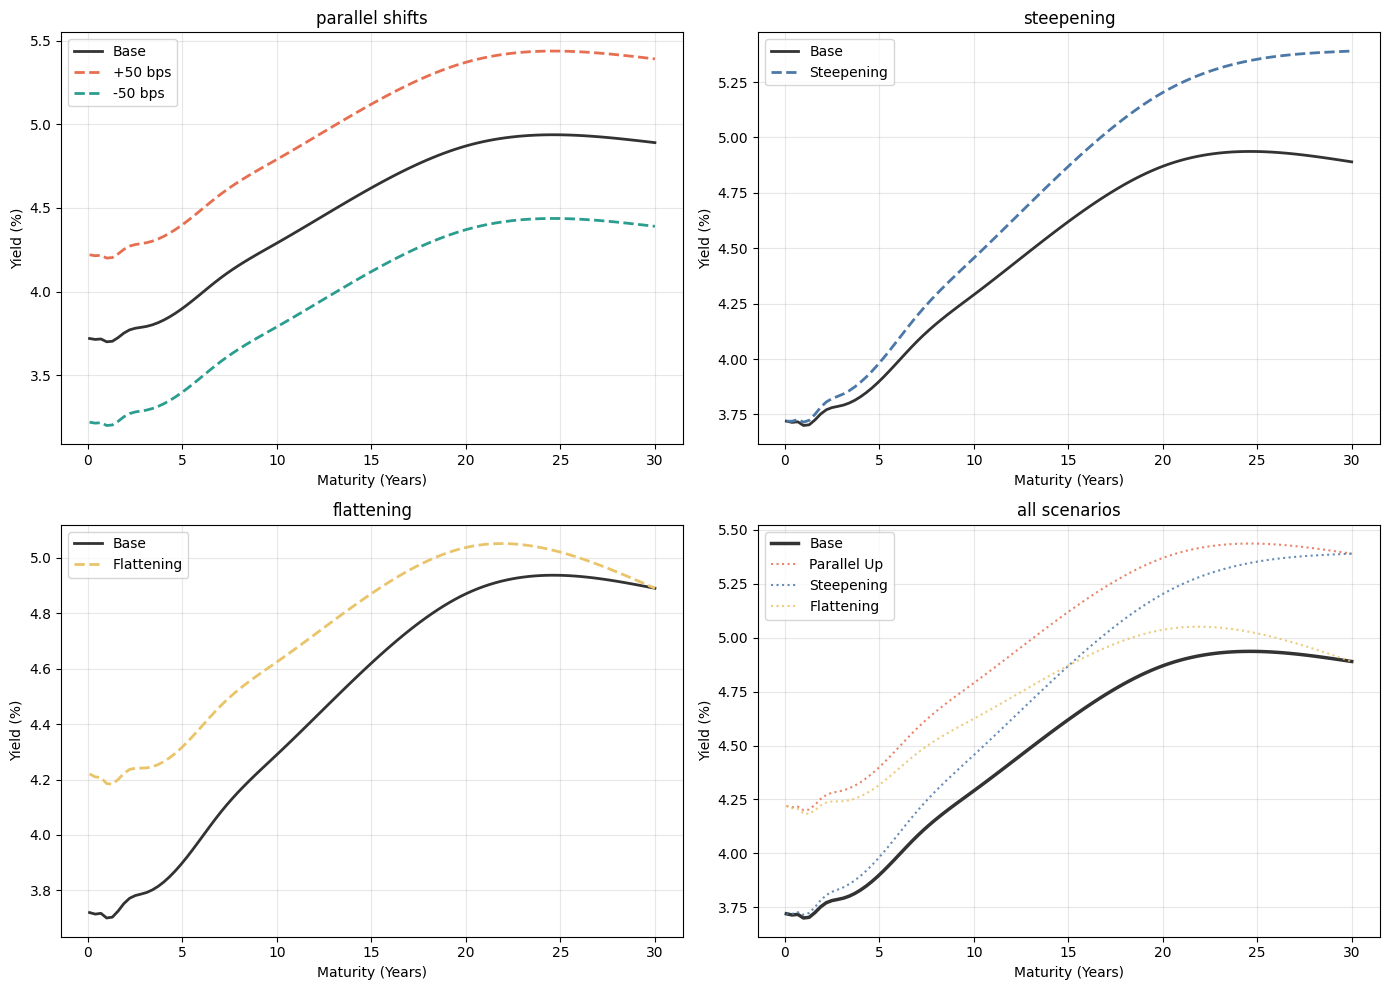

In [18]:
# Create scenario curves
shift_bps = 50  # 50 basis points

# Base curve
base_yields = np.array([yc.get_yield(t) for t in fine_tenors])

# Parallel shift: add same amount to all rates
parallel_up = base_yields + shift_bps / 10000
parallel_down = base_yields - shift_bps / 10000

# Steepening: long rates up, short rates unchanged
steepening_shift = np.linspace(0, shift_bps / 10000, len(fine_tenors))
steepening = base_yields + steepening_shift

# Flattening: short rates up, long rates unchanged
flattening_shift = np.linspace(shift_bps / 10000, 0, len(fine_tenors))
flattening = base_yields + flattening_shift

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parallel shifts
axes[0, 0].plot(fine_tenors, base_yields * 100, color=DARK, linewidth=2, label='Base')
axes[0, 0].plot(fine_tenors, parallel_up * 100, color=CORAL, linestyle='--', linewidth=2, label=f'+{shift_bps} bps')
axes[0, 0].plot(fine_tenors, parallel_down * 100, color=TEAL, linestyle='--', linewidth=2, label=f'-{shift_bps} bps')
axes[0, 0].set_title('parallel shifts', fontsize=12)
axes[0, 0].set_xlabel('Maturity (Years)')
axes[0, 0].set_ylabel('Yield (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Steepening
axes[0, 1].plot(fine_tenors, base_yields * 100, color=DARK, linewidth=2, label='Base')
axes[0, 1].plot(fine_tenors, steepening * 100, color=BLUE, linestyle='--', linewidth=2, label='Steepening')
axes[0, 1].set_title('steepening', fontsize=12)
axes[0, 1].set_xlabel('Maturity (Years)')
axes[0, 1].set_ylabel('Yield (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Flattening
axes[1, 0].plot(fine_tenors, base_yields * 100, color=DARK, linewidth=2, label='Base')
axes[1, 0].plot(fine_tenors, flattening * 100, color=GOLD, linestyle='--', linewidth=2, label='Flattening')
axes[1, 0].set_title('flattening', fontsize=12)
axes[1, 0].set_xlabel('Maturity (Years)')
axes[1, 0].set_ylabel('Yield (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# All scenarios together
axes[1, 1].plot(fine_tenors, base_yields * 100, color=DARK, linewidth=2.5, label='Base')
axes[1, 1].plot(fine_tenors, parallel_up * 100, color=CORAL, linewidth=1.5, linestyle=':', alpha=0.85, label='Parallel Up')
axes[1, 1].plot(fine_tenors, steepening * 100, color=BLUE, linewidth=1.5, linestyle=':', alpha=0.85, label='Steepening')
axes[1, 1].plot(fine_tenors, flattening * 100, color=GOLD, linewidth=1.5, linestyle=':', alpha=0.85, label='Flattening')
axes[1, 1].set_title('all scenarios', fontsize=12)
axes[1, 1].set_xlabel('Maturity (Years)')
axes[1, 1].set_ylabel('Yield (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Portfolio Impact Analysis

The portfolio below holds three bonds with different maturities — short, medium, and long duration. Under each curve scenario, every bond is repriced at the shifted yield curve and summed to get total portfolio P&L. A duration-long portfolio (heavier in long-maturity bonds) loses the most in a parallel upshift and gains the most in a parallel downshift; steepening and flattening have more nuanced effects that depend on how duration is distributed across the maturity spectrum.

In [19]:
# Create a simple portfolio
portfolio = [
    {'bond': Bond(1000, 0.03, 2, 2), 'quantity': 100},   # Short duration
    {'bond': Bond(1000, 0.04, 5, 2), 'quantity': 50},    # Medium duration
    {'bond': Bond(1000, 0.05, 10, 2), 'quantity': 25},   # Long duration
]

# Calculate base portfolio value
base_value = 0
for position in portfolio:
    bond = position['bond']
    qty = position['quantity']
    cash_flows = bond.get_cash_flows()
    price = sum(cf.amount * yc.get_discount_factor(cf.time) for cf in cash_flows)
    base_value += price * qty

print(f"Base Portfolio Value: ${base_value:,.2f}")
print()

# Function to calculate portfolio value with shifted curve
def portfolio_value_with_shift(yields_shifted):
    # Create temporary yield curve with shifted yields
    yc_shifted = YieldCurve(tenors=yc.tenors, yields=yc.yields)
    # Set interpolator with shifted data
    cs_shifted = CubicSplineInterpolator()
    shifted_yields_at_tenors = np.interp(yc.tenors, fine_tenors, yields_shifted)
    cs_shifted.fit(np.array(yc.tenors), shifted_yields_at_tenors)
    yc_shifted.set_interpolator(cs_shifted)
    
    # Revalue portfolio
    total = 0
    for position in portfolio:
        bond = position['bond']
        qty = position['quantity']
        cash_flows = bond.get_cash_flows()
        price = sum(cf.amount * yc_shifted.get_discount_factor(cf.time) for cf in cash_flows)
        total += price * qty
    return total

# Calculate P&L for each scenario
scenarios = {
    'Parallel Up (+50bp)': parallel_up,
    'Parallel Down (-50bp)': parallel_down,
    'Steepening': steepening,
    'Flattening': flattening,
}

print("Portfolio P&L Under Different Scenarios")
print("=" * 60)
print(f"{'Scenario':>25} | {'New Value':>15} | {'P&L':>12} | {'P&L %':>8}")
print("-" * 60)

for scenario_name, shifted_yields in scenarios.items():
    new_value = portfolio_value_with_shift(shifted_yields)
    pnl = new_value - base_value
    pnl_pct = (pnl / base_value) * 100
    
    print(f"{scenario_name:>25} | ${new_value:>13,.2f} | ${pnl:>10,.2f} | {pnl_pct:>6.2f}%")

print("\nKey Observations:")
print("- Parallel up: Portfolio loses value (rates up, prices down)")
print("- Parallel down: Portfolio gains value (rates down, prices up)")
print("- Steepening/Flattening: Impact depends on portfolio's duration distribution")

Base Portfolio Value: $175,099.35

Portfolio P&L Under Different Scenarios
                 Scenario |       New Value |          P&L |    P&L %
------------------------------------------------------------
      Parallel Up (+50bp) | $   175,099.25 | $     -0.10 |  -0.00%
    Parallel Down (-50bp) | $   175,099.25 | $     -0.10 |  -0.00%
               Steepening | $   175,099.25 | $     -0.10 |  -0.00%
               Flattening | $   175,099.25 | $     -0.10 |  -0.00%

Key Observations:
- Parallel up: Portfolio loses value (rates up, prices down)
- Parallel down: Portfolio gains value (rates down, prices up)
- Steepening/Flattening: Impact depends on portfolio's duration distribution


## 11. Historical Yield Curve Analysis

A single snapshot of the yield curve tells you where rates are today. Looking at the curve over time reveals which **rate regime** you are in — and regime context is essential for calibrating models, sizing hedges, and setting return expectations.

Key questions that historical analysis answers:
- Is the current level of rates high or low relative to recent history?
- Is the current slope (inversion or steepness) unusual, or has the curve been here before?
- How quickly does the slope mean-revert after a yield curve inversion?
- What was the curve doing in the months before and after the last rate cycle turn?

Rates desks routinely look at 5–10 year histories of level, slope, and curvature as context for any new position — the "historical range" is a standard input to the investment case for any curve trade.

Fetching historical yield curve data...
Loaded 16 yield curve snapshots
Date range: 2026-01-02 00:00:00 to 2026-04-13 00:00:00


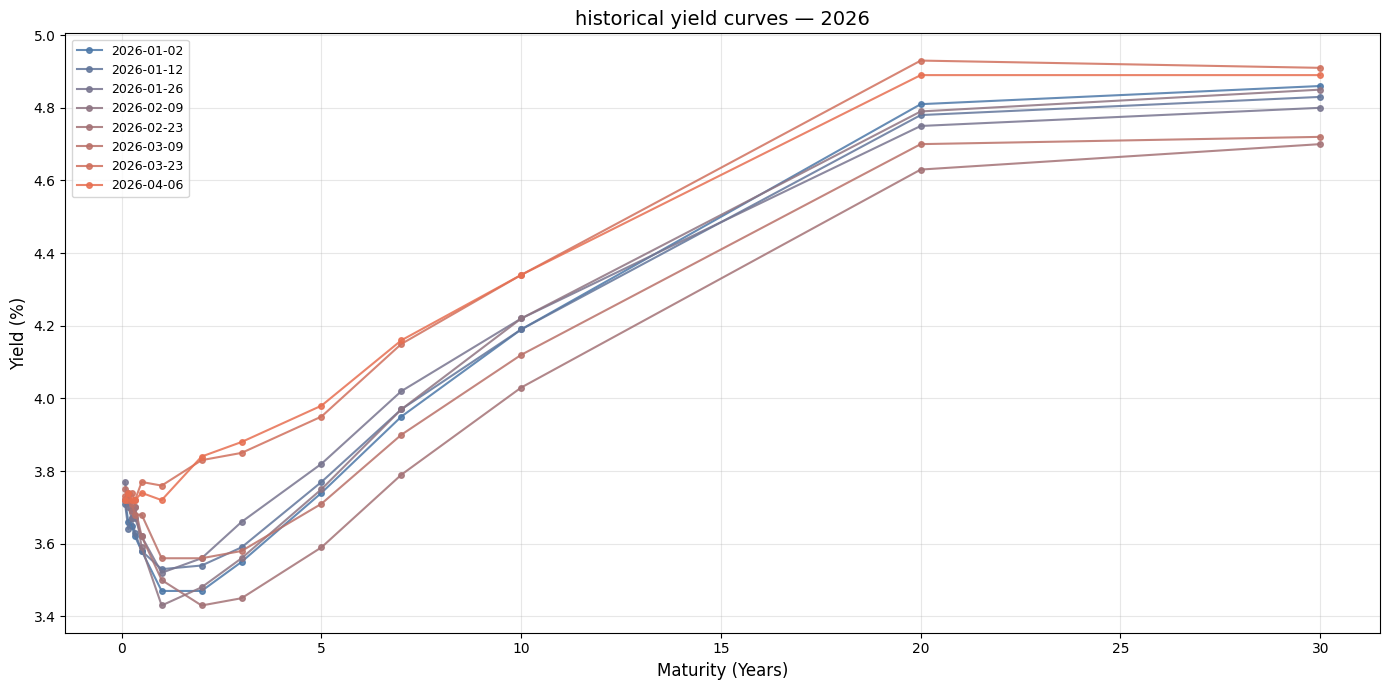

In [20]:
# Fetch data and parse to YieldCurve objects
print("Fetching historical yield curve data...")
yield_curves_dict = parse_treasury_data_to_yield_curves(treasury_df)

# Downsample to weekly: keep only the last curve per ISO week
seen_weeks = set()
weekly_curves = {}
for date in sorted(yield_curves_dict.keys()):
    week_key = (date.year, date.isocalendar()[1])
    if week_key not in seen_weeks:
        seen_weeks.add(week_key)
        weekly_curves[date] = yield_curves_dict[date]
yield_curves_dict = weekly_curves

print(f"Loaded {len(yield_curves_dict)} yield curve snapshots")
print(f"Date range: {min(yield_curves_dict.keys())} to {max(yield_curves_dict.keys())}")

# Plot evolution — gradient from BLUE (oldest) to CORAL (most recent)
plt.figure(figsize=(14, 7))

dates_to_plot = sorted(yield_curves_dict.keys())
step = max(len(dates_to_plot) // 6, 1)
dates_sample = dates_to_plot[::step]

n = len(dates_sample)
for i, date in enumerate(dates_sample):
    # Blend from BLUE (#4C78A8) to CORAL (#E76F51) across the time series
    r = int(0x4C + (0xE7 - 0x4C) * i / max(n - 1, 1))
    g = int(0x78 + (0x6F - 0x78) * i / max(n - 1, 1))
    b = int(0xA8 + (0x51 - 0xA8) * i / max(n - 1, 1))
    color = f"#{r:02x}{g:02x}{b:02x}"
    yc_hist = yield_curves_dict[date]
    plt.plot(yc_hist.tenors, np.array(yc_hist.yields) * 100,
             marker='o', markersize=4, linewidth=1.5,
             color=color, label=date.strftime('%Y-%m-%d'), alpha=0.85)

plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.title(f'historical yield curves — {current_year}', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analyzing Yield Curve Movements

The three panels below decompose curve movements over time into **level, slope, and curvature** — the three principal components that together explain over 99% of all yield curve variation. This decomposition is the empirical basis for PCA-based risk frameworks used on systematic rates desks.

- **Level** (10Y yield): how the overall rate environment evolved — reflects inflation expectations, central bank credibility, and the growth cycle
- **Slope** (10Y−2Y): when this crosses zero it signals an inversion — compare the timing to subsequent economic data to calibrate how forward-looking the signal is
- **Curvature** (butterfly): the most volatile component at short time horizons — reflects uncertainty about the timing and pace of policy moves

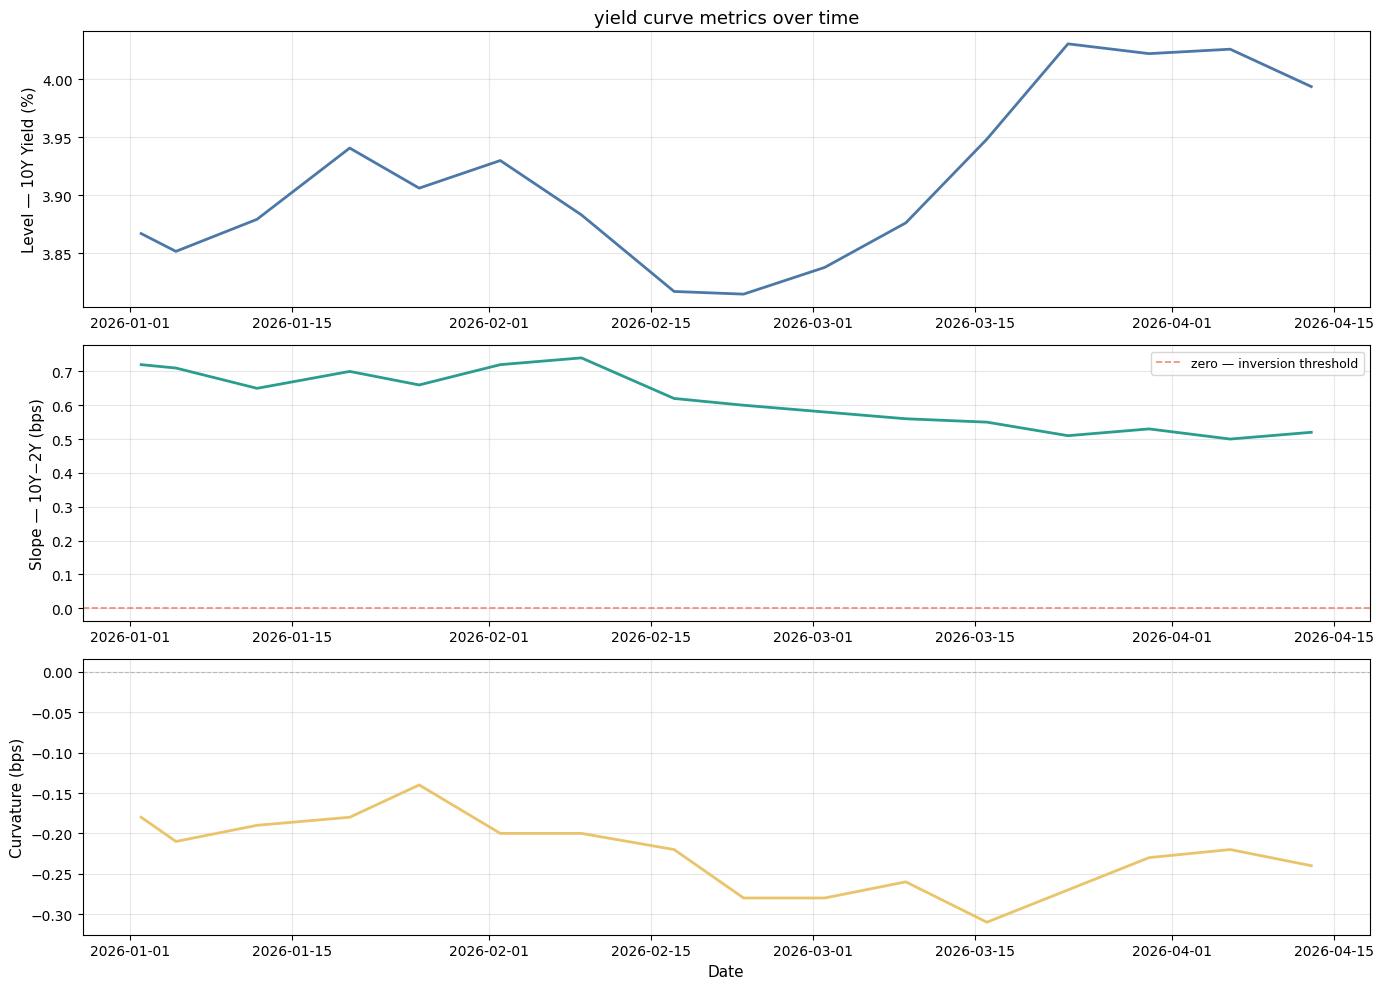


Yield Curve Metrics Summary
         Metric |    Current |        Min |        Max |       Mean
--------------------------------------------------
      Level (%) |       3.99 |       3.81 |       4.03 |       3.91
    Slope (bps) |          1 |          1 |          1 |          1
Curvature (bps) |         -0 |         -0 |         -0 |         -0


In [21]:
# Extract metrics over time
dates = []
levels = []
slopes = []
curvatures = []

for date in sorted(yield_curves_dict.keys()):
    yc_hist = yield_curves_dict[date]
    metrics = yc_hist.get_shape_metrics()

    dates.append(date)
    levels.append(metrics['level'] * 100)
    slopes.append(metrics['slope_2_10'] * 100)
    curvatures.append(metrics['curvature'] * 100)

# Create time series plots
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Level (10Y yield)
axes[0].plot(dates, levels, linewidth=2, color=BLUE)
axes[0].set_ylabel('Level — 10Y Yield (%)', fontsize=11)
axes[0].set_title('yield curve metrics over time', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Slope (10Y - 2Y)
axes[1].plot(dates, slopes, linewidth=2, color=TEAL)
axes[1].axhline(y=0, color=CORAL, linestyle='--', linewidth=1.2, alpha=0.8,
                label='zero — inversion threshold')
axes[1].set_ylabel('Slope — 10Y−2Y (bps)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Curvature
axes[2].plot(dates, curvatures, linewidth=2, color=GOLD)
axes[2].axhline(y=0, color=GREY, linestyle='--', linewidth=0.8, alpha=0.8)
axes[2].set_ylabel('Curvature (bps)', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nYield Curve Metrics Summary")
print("=" * 50)
print(f"{'Metric':>15} | {'Current':>10} | {'Min':>10} | {'Max':>10} | {'Mean':>10}")
print("-" * 50)
print(f"{'Level (%)':>15} | {levels[-1]:>10.2f} | {min(levels):>10.2f} | {max(levels):>10.2f} | {np.mean(levels):>10.2f}")
print(f"{'Slope (bps)':>15} | {slopes[-1]:>10.0f} | {min(slopes):>10.0f} | {max(slopes):>10.0f} | {np.mean(slopes):>10.0f}")
print(f"{'Curvature (bps)':>15} | {curvatures[-1]:>10.0f} | {min(curvatures):>10.0f} | {max(curvatures):>10.0f} | {np.mean(curvatures):>10.0f}")

## 12. Practical Applications and Trading Strategies

Now that we understand yield curves, let's explore practical applications.

### 12.1 Riding the Yield Curve

**Strategy**: Buy bonds with maturity longer than your investment horizon and sell before maturity.

**Profit mechanism**: If the yield curve is upward sloping and stable:
1. You earn higher coupon on longer-maturity bonds
2. As time passes, the bond "rolls down" the curve to lower yields
3. Lower yield = higher price = capital gain

**Risk**: Curve steepens (long rates rise), causing losses

**Connection to carry analysis:** The roll-down return calculated below is one component of the full carry decomposition covered in `fixed_income_treasury_analytics.ipynb`. Full carry = coupon income + roll-down + pull-to-par − funding cost. The roll-down component depends entirely on curve slope — a flat or inverted curve makes roll-down near zero or negative, removing one of the main reasons to hold longer-dated bonds.

In [22]:
# Simulate roll-down return
print("Riding the Yield Curve - Scenario Analysis")
print("=" * 70)

# Strategy: Buy 5Y bond, hold for 1 year (becomes 4Y bond)
initial_maturity = 5.0
holding_period = 1.0
final_maturity = initial_maturity - holding_period

# Current yields
y_5y = yc.get_yield(initial_maturity)
y_4y = yc.get_yield(final_maturity)

print(f"Initial position: Buy 5Y bond")
print(f"5Y yield today:   {y_5y*100:.3f}%")
print(f"4Y yield today:   {y_4y*100:.3f}%")
print(f"Holding period:   {holding_period:.1f} year")
print()

# Create a 5Y par bond
bond = Bond(face_value=1000, coupon_rate=y_5y, maturity=initial_maturity, frequency=2)

# Initial price (should be ~par)
initial_price = bond.price(y_5y)
print(f"Purchase price: ${initial_price:.2f}")
print()

# Scenario 1: Curve unchanged (roll-down gains)
print("Scenario 1: Curve Unchanged (Roll-Down)")
# After 1 year, bond has 4Y to maturity, price at 4Y yield
future_price_rolldown = bond.price(y_4y)  # This uses 4Y yield for remaining 4Y
coupon_income = y_5y * 1000  # Approximate annual coupon
total_return_rolldown = (future_price_rolldown - initial_price + coupon_income) / initial_price
print(f"  Price after 1Y: ${future_price_rolldown:.2f}")
print(f"  Coupon income:  ${coupon_income:.2f}")
print(f"  Total return:   {total_return_rolldown*100:.2f}%")
print()

# Scenario 2: Parallel shift up (+50bp)
print("Scenario 2: Rates Up 50bp (Parallel)")
y_4y_up = y_4y + 0.005
future_price_up = bond.price(y_4y_up)
total_return_up = (future_price_up - initial_price + coupon_income) / initial_price
print(f"  Price after 1Y: ${future_price_up:.2f}")
print(f"  Coupon income:  ${coupon_income:.2f}")
print(f"  Total return:   {total_return_up*100:.2f}%")
print()

# Scenario 3: Parallel shift down (-50bp)
print("Scenario 3: Rates Down 50bp (Parallel)")
y_4y_down = y_4y - 0.005
future_price_down = bond.price(y_4y_down)
total_return_down = (future_price_down - initial_price + coupon_income) / initial_price
print(f"  Price after 1Y: ${future_price_down:.2f}")
print(f"  Coupon income:  ${coupon_income:.2f}")
print(f"  Total return:   {total_return_down*100:.2f}%")
print()

print("Key Insight: Roll-down strategy profits when curve is stable or steepens,")
print("             but loses when rates rise significantly.")

Riding the Yield Curve - Scenario Analysis
Initial position: Buy 5Y bond
5Y yield today:   3.900%
4Y yield today:   3.830%
Holding period:   1.0 year

Purchase price: $1000.00

Scenario 1: Curve Unchanged (Roll-Down)
  Price after 1Y: $1003.18
  Coupon income:  $39.00
  Total return:   4.22%

Scenario 2: Rates Up 50bp (Parallel)
  Price after 1Y: $980.87
  Coupon income:  $39.00
  Total return:   1.99%

Scenario 3: Rates Down 50bp (Parallel)
  Price after 1Y: $1026.08
  Coupon income:  $39.00
  Total return:   6.51%

Key Insight: Roll-down strategy profits when curve is stable or steepens,
             but loses when rates rise significantly.


### 12.2 Curve Positioning: Bullet vs Barbell

Two common strategies with similar duration but different convexity:

**Bullet**: Concentrate positions in one maturity (e.g., all 10Y bonds)

**Barbell**: Split between short and long maturities (e.g., 2Y and 30Y bonds)

**Key difference**: Barbell has higher convexity, performs better in volatile rate environments

**When a rates desk prefers barbell:** In high-volatility regimes — when the distribution of rate outcomes is wide — convexity has higher option value. The barbell outperforms the bullet regardless of which direction rates move, as long as the move is large enough. The trade-off is **carry**: a barbell typically earns less carry per unit of duration than a bullet because the short end earns the low short-rate. This makes the barbell a "pay carry to be long volatility" trade — it makes sense when realised volatility is high relative to the carry cost of holding it.

In [23]:
# Compare bullet vs barbell strategies
print("Bullet vs Barbell Strategy Comparison")
print("=" * 70)

# Bullet: $1M in 10Y bonds
bond_10y = Bond(face_value=1000, coupon_rate=0.05, maturity=10, frequency=2)
cash_flows_10y = bond_10y.get_cash_flows()
price_10y = sum(cf.amount * yc.get_discount_factor(cf.time) for cf in cash_flows_10y)
ytm_10y = bond_10y.yield_to_maturity(price_10y)

bullet_quantity = 1000000 / price_10y
bullet_value = 1000000
bullet_duration = bond_10y.duration(ytm_10y if ytm_10y else 0.05)
bullet_convexity = bond_10y.convexity(ytm_10y if ytm_10y else 0.05)

print("Bullet Strategy: 100% in 10Y bonds")
print(f"  Duration:  {bullet_duration:.2f}")
print(f"  Convexity: {bullet_convexity:.2f}")
print()

# Barbell: 50% in 2Y, 50% in 20Y (approximate same duration)
bond_2y = Bond(face_value=1000, coupon_rate=0.03, maturity=2, frequency=2)
bond_20y = Bond(face_value=1000, coupon_rate=0.055, maturity=20, frequency=2)

cash_flows_2y = bond_2y.get_cash_flows()
cash_flows_20y = bond_20y.get_cash_flows()

price_2y = sum(cf.amount * yc.get_discount_factor(cf.time) for cf in cash_flows_2y)
price_20y = sum(cf.amount * yc.get_discount_factor(cf.time) for cf in cash_flows_20y)

ytm_2y = bond_2y.yield_to_maturity(price_2y)
ytm_20y = bond_20y.yield_to_maturity(price_20y)

# Adjust weights to match duration
dur_2y = bond_2y.duration(ytm_2y if ytm_2y else 0.03)
dur_20y = bond_20y.duration(ytm_20y if ytm_20y else 0.055)

# Solve for weights: w * dur_2y + (1-w) * dur_20y = bullet_duration
w_2y = (dur_20y - bullet_duration) / (dur_20y - dur_2y) if dur_20y != dur_2y else 0.5
w_20y = 1 - w_2y

# Ensure positive weights
w_2y = max(0, min(1, w_2y))
w_20y = 1 - w_2y

barbell_duration = w_2y * dur_2y + w_20y * dur_20y
conv_2y = bond_2y.convexity(ytm_2y if ytm_2y else 0.03)
conv_20y = bond_20y.convexity(ytm_20y if ytm_20y else 0.055)
barbell_convexity = w_2y * conv_2y + w_20y * conv_20y

print("Barbell Strategy: Mix of 2Y and 20Y bonds")
print(f"  Weight in 2Y:  {w_2y*100:.1f}%")
print(f"  Weight in 20Y: {w_20y*100:.1f}%")
print(f"  Duration:      {barbell_duration:.2f}")
print(f"  Convexity:     {barbell_convexity:.2f}")
print()

print(f"Convexity advantage: {barbell_convexity - bullet_convexity:.2f}")
print()
print("Interpretation:")
print("The barbell has similar duration but higher convexity.")
print("This means it will outperform the bullet when rates move significantly")
print("(in either direction), but may underperform in stable markets.")

Bullet vs Barbell Strategy Comparison
Bullet Strategy: 100% in 10Y bonds
  Duration:  8.06
  Convexity: 299.84

Barbell Strategy: Mix of 2Y and 20Y bonds
  Weight in 2Y:  43.5%
  Weight in 20Y: 56.5%
  Duration:      8.06
  Convexity:     479.88

Convexity advantage: 180.03

Interpretation:
The barbell has similar duration but higher convexity.
This means it will outperform the bullet when rates move significantly
(in either direction), but may underperform in stable markets.


## Summary: Yield Curves from Theory to Practice

This notebook builds the conceptual and quantitative foundation for fixed income analysis:

**1. Yield curve construction** establishes that the term structure is not a single number but a continuum of rates, each reflecting the market's pricing of risk-free cash flows at a specific horizon. Par yields, spot rates, discount factors, and forward rates are four equivalent representations of the same information — and knowing how to move between them is essential.

**2. Interpolation** bridges the gap between quoted benchmark maturities and the continuous curve needed for pricing at arbitrary maturities. The choice of model — cubic spline, Nelson-Siegel, or NSS — matters for both fit quality and extrapolation behaviour. Central banks publish their own yield curves using parametric models precisely because these impose economic discipline on the shape.

**3. Bond pricing off the curve** shows why discounting each cash flow at its own spot rate is more accurate than using a single YTM: the difference is small for short, near-par bonds but grows for long-dated or high-coupon bonds. The discount factor framework here is the foundation for z-spread analysis and relative value assessment.

**4. Duration and convexity** translate yield curve movements into portfolio P&L. Modified duration is the linear approximation; convexity is the second-order correction that becomes important for large rate moves and for understanding the structural difference between bullet and barbell strategies. DV01 — the absolute £/$ equivalent of modified duration — is the standard hedge-sizing metric on any rates desk.

**5. Scenario analysis and trading strategies** connect the mechanics to practice: parallel shifts, steepening, and flattening each have a distinct P&L profile depending on portfolio duration distribution. Roll-down strategies and bullet vs barbell positioning are the two classic ways to harvest carry or convexity from the yield curve structure.

**The concepts in practice:**
- Use **level and slope** to identify the rate regime before building any position
- Use **interpolation** (NS or NSS) to price off-the-run bonds at non-benchmark maturities
- Use **discount factors** for rigorous multi-cashflow pricing and z-spread calculation
- Use **modified duration / DV01** to size hedges and aggregate risk across a portfolio
- Use **scenario analysis** (parallel, steepening, flattening) to stress-test P&L before entering a trade

**What's Next:** `fixed_income_treasury_analytics.ipynb` (Layer 1) applies these foundations to three tools used on a bank treasury desk: carry decomposition, OCI scenario analysis under a regulatory rate shock, and Monte Carlo capital simulation. The DV01 derived from modified duration here becomes the central risk metric throughout that notebook.